Dataset:
       student_id  age  gender school_type parent_education  study_hours  \
24995       12047   17  female      public              phd          1.8   
24996        1102   16  female     private          diploma          2.7   
24997        4422   19   other     private    post graduate          1.0   
24998        7858   14    male     private          diploma          1.0   
24999       11621   18   other      public        no formal          0.7   

       attendance_percentage internet_access travel_time extra_activities  \
24995                   55.2             yes   15-30 min               no   
24996                   97.1             yes     <15 min               no   
24997                   63.0             yes     <15 min               no   
24998                   69.4             yes   15-30 min              yes   
24999                   60.3             yes   30-60 min               no   

      study_method  math_score  science_score  english_score  overall_s

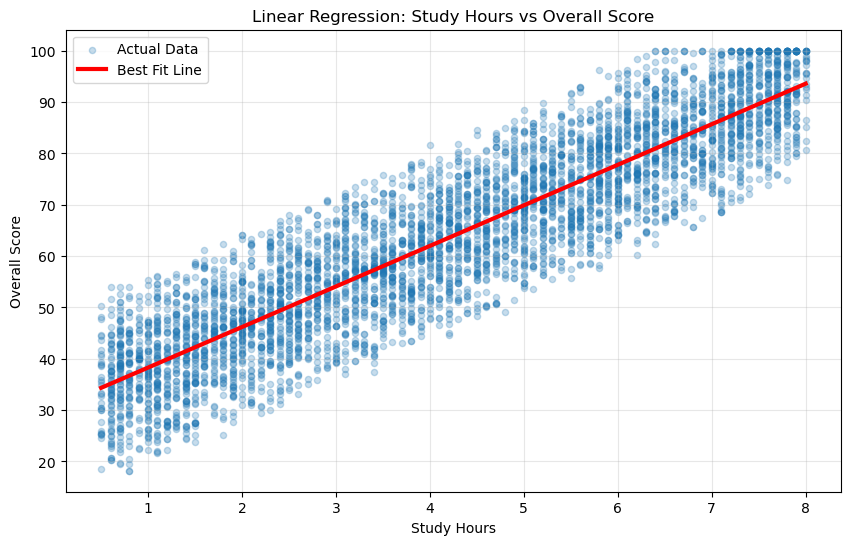

In [3]:
# Write a program to implement Linear regression on Jupyter notebook.

# a.     Download different datasets from Kaggle or UCI ML repository.

# b.     Import all the necessary modules for the datasets.

# c.    Find out the best fit line along with the MSE, RMSE.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv(r"C:\Users\ASUS\Downloads\Student_Performance.csv")

# Display dataset
print("Dataset:")
print(df.tail())

# Select independent and dependent variables
X = df[['study_hours']]
y = df['overall_score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Find slope and intercept
m = model.coef_[0]
c = model.intercept_

print("\nSlope:", m)
print("Intercept:", c)

# Best fit line
print(f"\nBest Fit Line:")
print(f"Overall Score = {m:.2f} × Study Hours + {c:.2f}")

# Prediction
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

print("\nMSE:", mse)
print("RMSE:", rmse)

# Plot regression line
plt.figure(figsize=(10, 6))

# Scatter plot of actual test data
plt.scatter(
    X_test,
    y_test,
    alpha=0.25,
    s=20,
    label="Actual Data"
)

# Sort values so the regression line is smooth
sorted_indices = X_test['study_hours'].argsort()
X_sorted = X_test.iloc[sorted_indices]
y_sorted_pred = y_pred[sorted_indices]

# Best fit line
plt.plot(
    X_sorted,
    y_sorted_pred,
    color='red',
    linewidth=3,
    label="Best Fit Line"
)

plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.title("Linear Regression: Study Hours vs Overall Score")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()